In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/creditcard_2023.csv')


In [34]:
# Basic Info
print(df.shape)        # (568630, 31)
print(df.head())
print(df.info())


(392743, 31)
   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2   2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3   3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4   4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.130006  0.727159  ... -0.110552  0.217606 -0.134794  0.165959  0.126280   
1 -0.133118  0.347452  ... -0.194936 -0.605761  0.079469 -0.577395  0.190090   
2 -0.095576 -0.261297  ... -0.005020  0.702906  0.945045 -1.154666 -0.605564   
3 -0.065130 -0.205698  ... -0.146927 -0.038212 -0.214048 -1.893131  1.003963   
4 -0.212660  1.049921  ... -0.106984  0.729727 -0.161666  0.312561 -0.414116   

        V26       V27       V28

In [35]:
print(df.isnull().sum())  # Missing values check

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [36]:
# drop the null values bcoz of count is very low

In [37]:
df.dropna(inplace=True)

In [38]:
# Class Distribution
print(df['Class'].value_counts())

Class
0.0    284315
1.0    108427
Name: count, dtype: int64


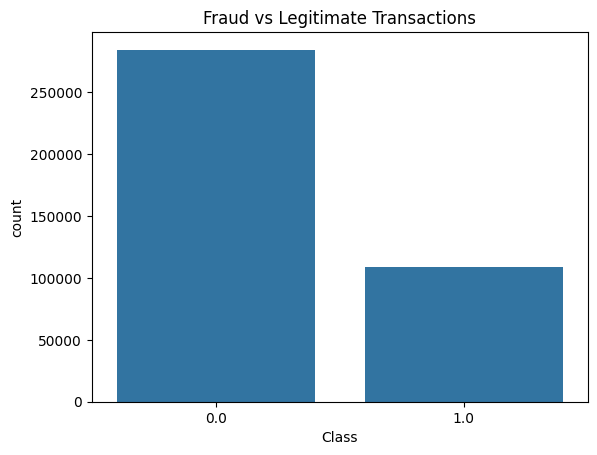

In [39]:
# Visualize
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.show()

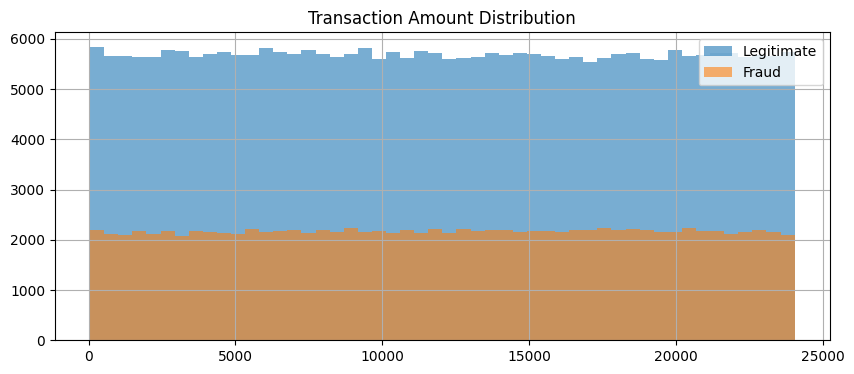

In [40]:
# Amount Distribution
plt.figure(figsize=(10,4))
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.6, label='Legitimate')
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title('Transaction Amount Distribution')
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & Target
X = df.drop(['id', 'Class'], axis=1)
y = df['Class']



In [42]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← Class balance maintain
)


In [43]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size: (314193, 29)
Test size : (78549, 29)


In [44]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0.0: 227452, 1.0: 86741}
After SMOTE: {1.0: 227452, 0.0: 227452}


In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2


In [57]:

# ANN Architecture
model = Sequential([

    # Input Layer
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    # Hidden Layer 1
    #Dense(32, activation='relu'),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    # Hidden Layer 2
    Dense(16, activation='relu',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(4, activation='relu',kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    # Output Layer (Binary Classification)
    Dense(1, activation='sigmoid')
])

# Model Summary
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,769 (30.35 KB)

 Trainable params: 7,481 (29.22 KB)

 Non-trainable params: 288 (1.12 KB)

In [58]:
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

In [59]:
# Use Early stopping to Avoid Overfitting

In [61]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)  # e.g. {0: 0.54, 1: 113.5}


{0: np.float64(0.6906797917802437), 1: np.float64(1.8110985577754464)}


In [62]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_auc',       # ← change from val_loss
    patience=7,
    mode='max',              # ← higher AUC is better
    restore_best_weights=True
)
# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=500,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop,checkpoint],
    verbose=1
)

Epoch 1/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - auc: 0.9978 - loss: 0.0451 - precision: 0.9576 - recall: 0.9957

503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9868 - auc: 0.9978 - loss: 0.0443 - precision: 0.9576 - recall: 0.9963 - val_accuracy: 0.9986 - val_auc: 0.9999 - val_loss: 0.0104 - val_precision: 0.9957 - val_recall: 0.9994
Epoch 2/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9866 - auc: 0.9978 - loss: 0.0436 - precision: 0.9568 - recall: 0.9965 - val_accuracy: 0.9987 - val_auc: 0.9999 - val_loss: 0.0106 - val_precision: 0.9963 - val_recall: 0.9988
Epoch 3/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9869 - auc: 0.9979 - loss: 0.0429 - precision: 0.9573 - recall: 0.9969 - val_accuracy: 0.9979 - val_auc: 0.9999 - val_loss: 0.0119 - val_precision: 0.9930 - val_recall: 0.9994
Epoch 4/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9869 - auc: 0.9979 - loss: 0.0428 - precision: 0.9577 - recall: 0.9966 - val_accuracy: 0.9986 - val_auc: 0.9999 - val_loss: 0.0104 - val_precision: 0.9958 - val_recall: 0.9990
Epoch 5/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2

503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9871 - auc: 0.9979 - loss: 0.0415 - precision: 0.9582 - recall: 0.9968 - val_accuracy: 0.9985 - val_auc: 0.9999 - val_loss: 0.0109 - val_precision: 0.9954 - val_recall: 0.9993
Epoch 7/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9865 - auc: 0.9979 - loss: 0.0428 - precision: 0.9565 - recall: 0.9966 - val_accuracy: 0.9988 - val_auc: 0.9999 - val_loss: 0.0097 - val_precision: 0.9966 - val_recall: 0.9990
Epoch 8/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9870 - auc: 0.9980 - loss: 0.0416 - precision: 0.9578 - recall: 0.9968 - val_accuracy: 0.9986 - val_auc: 0.9999 - val_loss: 0.0103 - val_precision: 0.9951 - val_recall: 0.9998
Epoch 9/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - auc: 0.9981 - loss: 0.0398 - precision: 0.9602 - recall: 0.9971 - val_accuracy: 0.9985 - val_auc: 0.9999 - val_loss: 0.0109 - val_precision: 0.9950 - val_recall: 0.9996
Epoch 10/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s

503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9878 - auc: 0.9980 - loss: 0.0400 - precision: 0.9601 - recall: 0.9971 - val_accuracy: 0.9987 - val_auc: 0.9999 - val_loss: 0.0099 - val_precision: 0.9955 - val_recall: 0.9998
Epoch 13/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9879 - auc: 0.9981 - loss: 0.0387 - precision: 0.9604 - recall: 0.9971 - val_accuracy: 0.9985 - val_auc: 0.9999 - val_loss: 0.0102 - val_precision: 0.9949 - val_recall: 0.9996
Epoch 14/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9876 - auc: 0.9980 - loss: 0.0400 - precision: 0.9596 - recall: 0.9971 - val_accuracy: 0.9985 - val_auc: 0.9999 - val_loss: 0.0104 - val_precision: 0.9962 - val_recall: 0.9984
Epoch 15/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9875 - auc: 0.9979 - loss: 0.0403 - precision: 0.9593 - recall: 0.9969 - val_accuracy: 0.9984 - val_auc: 0.9999 - val_loss: 0.0099 - val_precision: 0.9946 - val_recall: 0.9995
Epoch 16/50
503/503 ━━━━━━━━━━━━━━━━━━━━

In [63]:
y_pred_prob = model.predict(X_test)          # Probability (0 to 1)


2455/2455 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [64]:
y_pred_prob

array([[9.9907374e-01],
       [1.0843895e-10],
       [7.7378850e-09],
       ...,
       [1.7073025e-10],
       [9.9943286e-01],
       [1.5279690e-10]], dtype=float32)

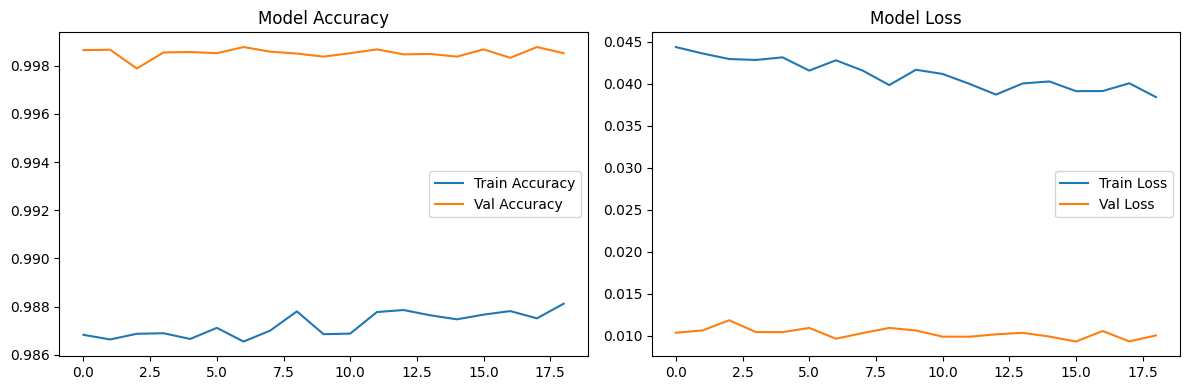

In [65]:
# Accuracy Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              roc_curve)

ROC-AUC Score: 0.9998


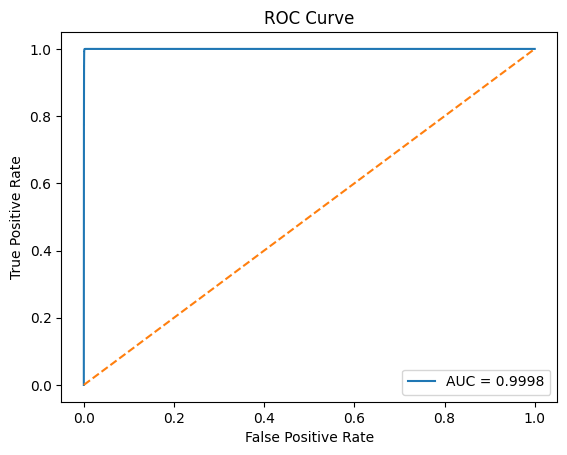

In [67]:

# ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [68]:
# Score 0.9881

2455/2455 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       0.99      1.00      1.00     21686

    accuracy                           1.00     78549
   macro avg       1.00      1.00      1.00     78549
weighted avg       1.00      1.00      1.00     78549



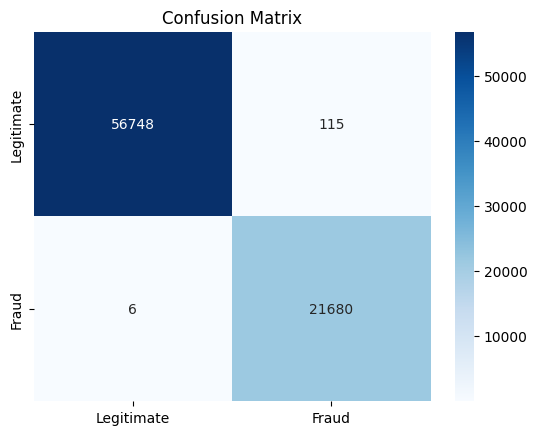

In [69]:


# Predict
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'])
plt.title('Confusion Matrix')
plt.show()